In [11]:
import xarray as xr
import pandas as pd
import dask
import glob
import os
import math

In [12]:
import numpy as np
import re
import matplotlib.pyplot as plt

In [13]:
%run ~/analysis_tools/functions.py
%run ~/analysis_tools/mask_analysis.py
%run ../funs/plotting.py

In [14]:

#obs_ds = xr.open_dataset("/glade/work/qingyuany/cam7_re/obs.nc")

obs_ds = xr.open_dataset("~/satellite_obs/obs_interp_cam6.nc")
obs_ds["pr"] = obs_ds["pr"]/(1000 * 86400)

In [15]:
# obs_dict = {
#  'RESTOM': 'toa_net_all_mon',
#  'FSNT': 'fsnt',
#  'FLNT': 'toa_lw_all_mon',
#  'SWCF': 'toa_cre_sw_mon',
#  'LWCF': 'toa_cre_lw_mon',
#  'PRECT': 'PRECT',
#  'TGCLDLWP': 'TGCLDLWP',
#  'FSNTC': 'toa_sw_clr_t_mon',
#  #'FLUTC': 'toa_lw_clr_t_mon',
#  'TMQ': 'PREH2O',
#  'LHFLX': 'LHFLX'}

#obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TGCLDLWP": "clwp", "TMQ": "pwv",
#          "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}




obs_dict = {"SWCF": "swcrf_toa", "LWCF": "lwcrf_toa", "TMQ": "pwv",
           "FLUT": "olr", "PRECT": "pr","FSNTOA": "swabs_toa"}

In [16]:
cli_nms = list(obs_dict.keys())



In [17]:
ppev0 = xr.open_dataset("/glade/work/qingyuany/camml_re/v0/initial_ppe.nc")
#ppev0['RESTOM'] = ppev0["FSNT"] - ppev0["FLNT"]
ppev1 = xr.open_dataset('/glade/work/qingyuany/camml_re/v1/post_simulations/batch_v1.nc')
ppev1_b = xr.open_dataset('/glade/work/qingyuany/camml_re/v1_b/post_simulations/batch_v1_b.nc')
ppev2 = xr.open_dataset('/glade/work/qingyuany/camml_re/v2/post_simulations/batch_v2.nc')
ppev2_v1b = xr.open_dataset('/glade/work/qingyuany/camml_re/v2_v1_b/post_simulations/batch_v2_v1_b.nc')

ppev2_b = xr.open_dataset('/glade/work/qingyuany/camml_re/v2_b/post_simulations/batch_v2_b.nc')
ppev2_c = xr.open_dataset('/glade/work/qingyuany/camml_re/v2_c/post_simulations/batch_v2_c.nc')
ppev2_d = xr.open_dataset('/glade/work/qingyuany/camml_re/v2_d/post_simulations/batch_v2_d.nc')

ppe2025 = xr.open_dataset('/glade/work/qingyuany/camml_re/2025_v4/batch_2025_v4.nc')
ppe_filter_v1 = xr.open_dataset('/glade/work/qingyuany/camml_re/v1_filter_extreme/post_simulation/batch_filter_v1.nc')


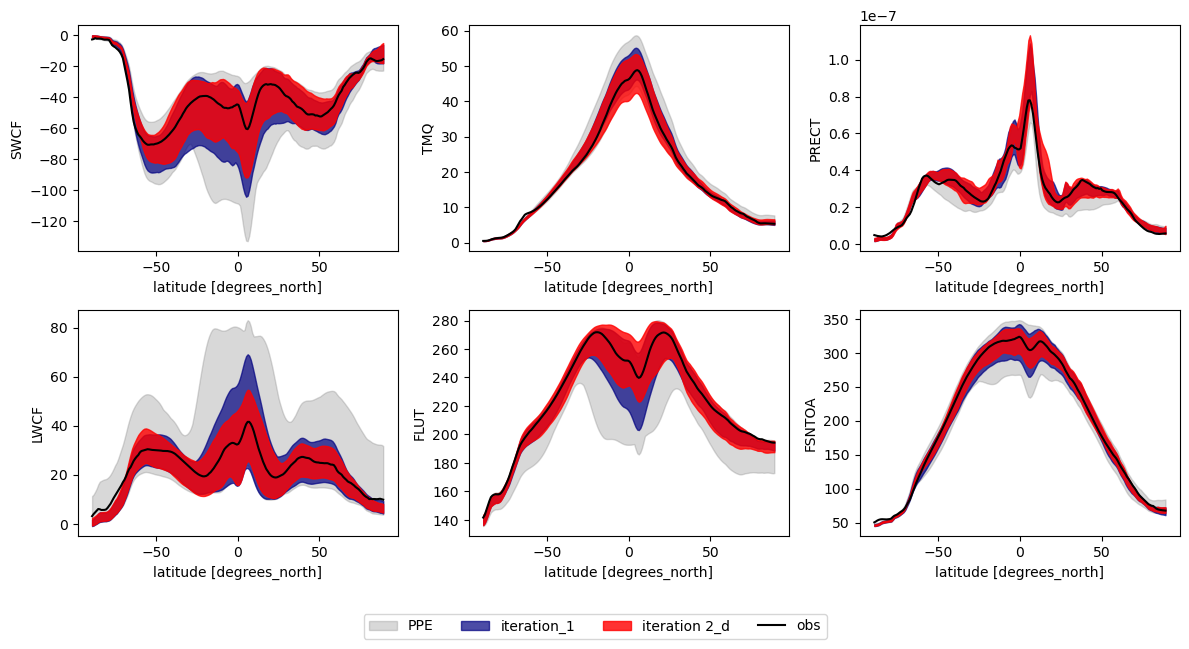

In [18]:
fig, axes = plt.subplots(2, 3, figsize = (12, 6))


for i, (cli_nm, obs_nm) in enumerate(obs_dict.items()):
    
    sim_temp_v0 = ppev0[cli_nm]
    sim_temp_v0 = sim_temp_v0.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v1 = ppev1[cli_nm]
    sim_temp_v1 = sim_temp_v1.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v1_b = ppev1_b[cli_nm]
    sim_temp_v1_b = sim_temp_v1_b.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2 = ppev2[cli_nm]
    sim_temp_v2 = sim_temp_v2.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_v1b = ppev2_v1b[cli_nm]
    sim_temp_v2_v1b = sim_temp_v2_v1b.where(~obs_ds[obs_nm].isnull(), drop = True)
    
    
    sim_temp_v2_b = ppev2_b[cli_nm]
    sim_temp_v2_b = sim_temp_v2_b.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_c = ppev2_c[cli_nm]
    sim_temp_v2_c = sim_temp_v2_c.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_d = ppev2_d[cli_nm]
    sim_temp_v2_d = sim_temp_v2_d.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v1_filter = ppe_filter_v1[cli_nm]
    sim_temp_v1_filter = sim_temp_v1_filter.where(~obs_ds[obs_nm].isnull(), drop = True)


    
    
    ax = axes[i%2, math.floor(i/2)] 

    ax.fill_between(sim_temp_v0.lat, sim_temp_v0.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v0.mean(dim = "lon").min(dim = "ppe_ind"), 
                    color = "gray", label = "PPE", alpha = 0.3)

    ax.fill_between(sim_temp_v1.lat, sim_temp_v1.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v1.mean(dim = "lon").min(dim = "ppe_ind"), 
                    color = "navy", label = "iteration_1", alpha = 0.7)

    # ax.fill_between(sim_temp_v2.lat, sim_temp_v2.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v2.mean(dim = "lon").min(dim = "ppe_ind"), 
    #                  color = "green", label = "iteration 2_b", alpha = 0.8)

    # ax.fill_between(sim_temp_v2_c.lat, sim_temp_v2_c.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v2_c.mean(dim = "lon").min(dim = "ppe_ind"), 
    #                  color = "navy", label = "envelope", alpha = 0.2)

    ax.fill_between(sim_temp_v1_filter.lat, sim_temp_v1_filter.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v2_v1b.mean(dim = "lon").min(dim = "ppe_ind"), 
                    color = "red", label = "iteration 2_d", alpha = 0.8)

    obs_ds[obs_nm].mean(dim = "lon").plot(ax = ax, color = "black", label = "obs")
        
    ax.set_ylabel(cli_nm)

handles, labels = ax.get_legend_handles_labels()

# Create a single legend at the bottom
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4)

plt.tight_layout()

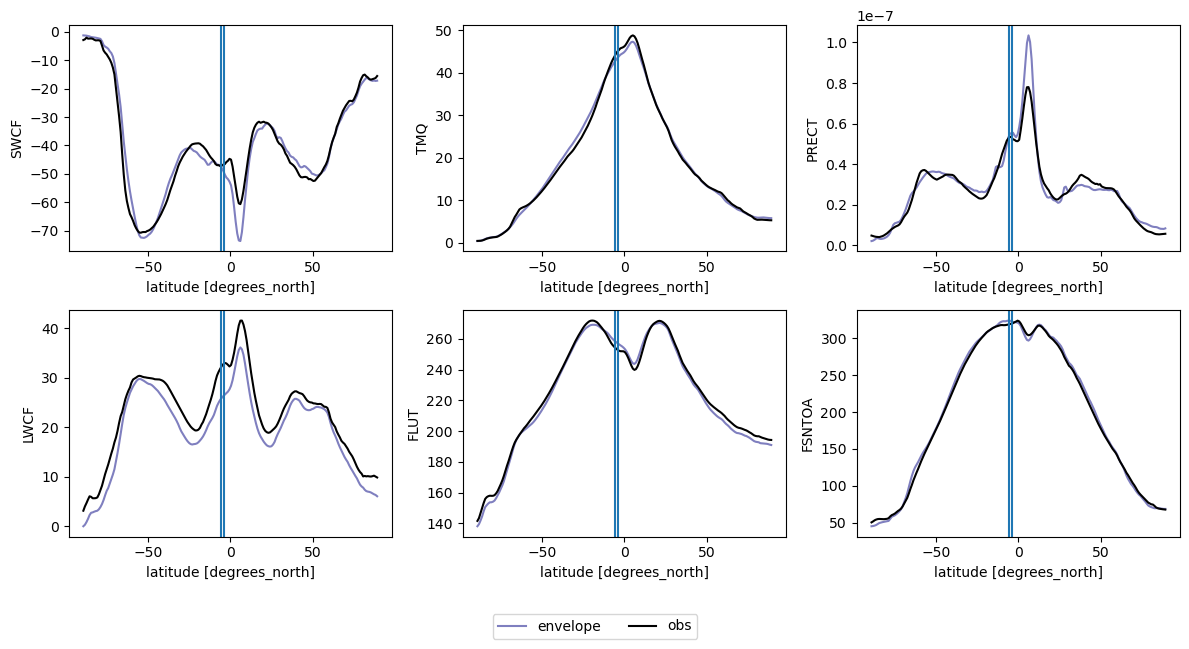

In [21]:
fig, axes = plt.subplots(2, 3, figsize = (12, 6))


for i, (cli_nm, obs_nm) in enumerate(obs_dict.items()):
    
    sim_temp_v0 = ppev0[cli_nm]
    sim_temp_v0 = sim_temp_v0.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v1 = ppev1[cli_nm]
    sim_temp_v1 = sim_temp_v1.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2 = ppev2[cli_nm]
    sim_temp_v2 = sim_temp_v2.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v1_b = ppev1_b[cli_nm]
    sim_temp_v1_b = sim_temp_v1_b.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_b = ppev2_b[cli_nm]
    sim_temp_v2_b = sim_temp_v2_b.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_c = ppev2_c[cli_nm]
    sim_temp_v2_c = sim_temp_v2_c.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_d = ppev2_d[cli_nm]
    sim_temp_v2_d = sim_temp_v2_d.where(~obs_ds[obs_nm].isnull(), drop = True)

    sim_temp_v2_v1b = ppev2_v1b[cli_nm]
    sim_temp_v2_v1b = sim_temp_v2_v1b.where(~obs_ds[obs_nm].isnull(), drop = True)


    sim_temp_v2025 = ppe2025[cli_nm]
    sim_temp_v2025 = sim_temp_v2025.where(~obs_ds[obs_nm].isnull(), drop = True)


    sim_temp_v1_filter = ppe_filter_v1[cli_nm]
    sim_temp_v1_filter = sim_temp_v1_filter.where(~obs_ds[obs_nm].isnull(), drop = True)

    
    ax = axes[i%2, math.floor(i/2)] 

    # ax.fill_between(sim_temp_v0.lat, sim_temp_v0.mean(dim = "lon").max(dim = "ppe_ind"), sim_temp_v0.mean(dim = "lon").min(dim = "ppe_ind"), 
    #                 color = "gray", label = "envelope", alpha = 0.3)

    
    ax.plot(sim_temp_v1_filter.lat, sim_temp_v1_filter.mean(dim = "lon").sel(ppe_ind = 58), 
                    color = "navy", label = "envelope", alpha = 0.5)

    obs_ds[obs_nm].mean(dim = "lon").plot(ax = ax, color = "black", label = "obs")
        
    ax.set_ylabel(cli_nm)
    ax.axvline(-5.5)
    ax.axvline(-4)
handles, labels = ax.get_legend_handles_labels()

# Create a single legend at the bottom
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4)

plt.tight_layout()